In [ ]:
## Image processing and computer vision
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
img = cv2.imread('C:\\Users\\Harshit Sharma\\Downloads\\Vscode\\BootCamp\\Images.jpeg')
print(type(img))


<class 'numpy.ndarray'>


In [ ]:
# printing the image shape and displaying the image
print(img.shape)
cv2.imshow("photos",img)
cv2.waitKey(0)

(2160, 3840, 3)


In [ ]:
# for resizing the image 
img_resize =cv2.resize(img,(450,256))
cv2.imshow("photos",img_resize)
cv2.waitKey(0)

-1

In [ ]:
# flipping the image
img_flip = cv2.flip(img,0)
cv2.imshow("photos",img_flip)
cv2.waitKey(0)

-1

In [ ]:
# for cropping the image
img_crop = img[100:300,200:500]
cv2.imshow("photos",img_crop)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
## Capturing a image
import cv2

# Initialize the webcam (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Check if the webcam is opened correctly
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Capture a single frame
ret, frame = cap.read()

if ret:
    # Display the frame in a window
    cv2.imshow('Captured Frame', frame)
    
    # Wait for a key press to close the window
    cv2.waitKey(0)

# Release the webcam and close the window
cap.release()
cv2.destroyAllWindows()

In [22]:
## Video Processing
import cv2

# Initialize the webcam (0 is usually the default camera)
cap = cv2.VideoCapture(0)

# Check if the webcam is opened correctly
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

# Loop to continuously capture frames
while True:
    # Capture each frame
    ret, frame = cap.read()

    # If the frame is captured successfully
    if ret:
        # Display the frame in a window
        cv2.imshow('Webcam Feed', frame)

        # Wait for 1 ms and check if 'q' is pressed to quit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        print("Error: Failed to capture frame.")
        break

# Release the webcam and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()

In [ ]:
## Detecting the object in the image

import cv2
from ultralytics import settings

# Disable data and crash report tracking
settings.update({"sync": False})
from ultralytics import YOLO

# 1. Load the lightweight YOLOv8 Nano model (~6MB, runs fast on CPU)
model = YOLO('yolov8n.pt')

# 2. Open the webcam (0 is default built-in camera)
cap = cv2.VideoCapture(0)

print("Starting Object Counter... Press 'q' on the video window to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    print("Failed to grab camera frame.")
    break

  # 3. Perform object detection on the current frame
  results = model(frame, verbose=False)

  # Get total number of objects detected in this frame
  detected_count = len(results[0].boxes)

  # 4. Render detection boxes directly on the frame
  annotated_frame = results[0].plot()

  # 5. Display the object count overlay on screen
  cv2.putText(
      annotated_frame,
      f'Total Objects Counted: {detected_count}',
      (20, 50),  # Position (x, y)
      cv2.FONT_HERSHEY_SIMPLEX,
      1,  # Font scale
      (0, 255, 0),  # Text color (Green)
      2,  # Thickness
      cv2.LINE_AA,
  )

  # 6. Show the frame in a window
  cv2.imshow('BCA AI Demo - Live Object Counter', annotated_frame)

  # 7. Terminate program cleanly when pressing 'q'
  if cv2.waitKey(1) & 0xFF == ord('q'):
    print("Terminating program...")
    break

# Release camera and close all windows cleanly
cap.release()

# 2. Add short wait key loops to let Windows pump destroy events cleanly
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

print("Camera feed closed successfully.")

Starting Object Counter... Press 'q' on the video window to quit.
Terminating program...
Camera feed closed successfully.


In [ ]:
## Drawing Canvas
import cv2
import numpy as np

# 1. Initialize Webcam (CAP_DSHOW prevents camera light freeze on Windows)
cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

# 2. Define HSV Color Range for a BLUE object (Default)
# Tip: Adjust lower/upper bounds if using a Red/Green object!
LOWER_COLOR = np.array([100, 150, 0])  # Lower bound for Blue in HSV
UPPER_COLOR = np.array([140, 255, 255])  # Upper bound for Blue in HSV

canvas = None
prev_point = None

print("Air Canvas Started! Wave a BLUE marker in front of the camera to draw.")
print("Press 'c' to clear canvas. Press 'q' to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    break

  # Flip frame horizontally for intuitive "mirror" drawing
  frame = cv2.flip(frame, 1)

  # Initialize black canvas to match camera size on first frame
  if canvas is None:
    canvas = np.zeros_like(frame)

  # --- CORE CV CONCEPTS FOR STUDENTS ---

  # A. Convert BGR to HSV color space (easier to isolate specific colors)
  hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

  # B. Create binary mask (White = color detected, Black = background)
  mask = cv2.inRange(hsv, LOWER_COLOR, UPPER_COLOR)

  # Clean noise using morphological erosion and dilation
  mask = cv2.erode(mask, None, iterations=1)
  mask = cv2.dilate(mask, None, iterations=1)

  # C. Find contours (outlines of detected shapes)
  contours, _ = cv2.findContours(
      mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
  )

  curr_point = None

  if contours:
    # Get the largest contour (prevents small background noise from drawing)
    largest_contour = max(contours, key=cv2.contourArea)

    # Filter out tiny detections by minimum area threshold
    if cv2.contourArea(largest_contour) > 500:
      # Calculate centroid (center x, y coordinates) of detected marker
      M = cv2.moments(largest_contour)
      if M['m00'] != 0:
        cX = int(M['m10'] / M['m00'])
        cY = int(M['m01'] / M['m00'])
        curr_point = (cX, cY)

        # Draw a visual tracking dot around object tip
        cv2.circle(frame, curr_point, 8, (0, 255, 255), -1)

  # D. Draw lines on the canvas when object moves
  if curr_point and prev_point:
    cv2.line(canvas, prev_point, curr_point, (0, 0, 255), 5)  # Red ink line

  prev_point = curr_point

  # Combine live webcam feed and drawing canvas together
  combined = cv2.add(frame, canvas)

  # Display UI instructions
  cv2.putText(
      combined,
      "Press 'c' to Clear | Press 'q' to Quit",
      (10, 30),
      cv2.FONT_HERSHEY_SIMPLEX,
      0.7,
      (255, 255, 255),
      2,
  )

  cv2.imshow('BCA AI Demo - Virtual Air Canvas', combined)

  key = cv2.waitKey(1) & 0xFF
  if key == ord('c'):
    canvas = np.zeros_like(frame)  # Clear canvas
  elif key == ord('q'):
    break

# Clean up webcam resources cleanly
cap.release()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

Air Canvas Started! Wave a BLUE marker in front of the camera to draw.
Press 'c' to clear canvas. Press 'q' to quit.


-1

In [ ]:
## Creating a WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Ensure necessary NLTK data is downloaded
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Harshit
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\Harshit
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [2]:
text = """
I use a **Lenovo Yoga Slim 7i** laptop, which is a thin and lightweight laptop designed for both everyday use 
and performance. My laptop is equipped with an **Intel Core Ultra 9 processor** and 
is mainly used for **college work, programming, VS Code, Jupyter Notebook, web browsing, and 
other academic tasks**. It has an **OLED display**, which provides sharp visuals and good contrast. 
I also pay attention to its **battery health, charging behavior, temperature, fan noise, and 
performance**, especially because I use it regularly for programming and college work. 
Overall, it serves as my main device for **B.Tech CSE studies, coding, projects, 
and general day-to-day computing**.
"""
print(text)


I use a **Lenovo Yoga Slim 7i** laptop, which is a thin and lightweight laptop designed for both everyday use 
and performance. My laptop is equipped with an **Intel Core Ultra 9 processor** and 
is mainly used for **college work, programming, VS Code, Jupyter Notebook, web browsing, and 
other academic tasks**. It has an **OLED display**, which provides sharp visuals and good contrast. 
I also pay attention to its **battery health, charging behavior, temperature, fan noise, and 
performance**, especially because I use it regularly for programming and college work. 
Overall, it serves as my main device for **B.Tech CSE studies, coding, projects, 
and general day-to-day computing**.



In [4]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to C:\Users\Harshit
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Harshit
[nltk_data]     Sharma\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [5]:
words = word_tokenize(text.lower())  # Convert to lowercase for uniformity
print(words)

['i', 'use', 'a', '*', '*', 'lenovo', 'yoga', 'slim', '7i', '*', '*', 'laptop', ',', 'which', 'is', 'a', 'thin', 'and', 'lightweight', 'laptop', 'designed', 'for', 'both', 'everyday', 'use', 'and', 'performance', '.', 'my', 'laptop', 'is', 'equipped', 'with', 'an', '*', '*', 'intel', 'core', 'ultra', '9', 'processor', '*', '*', 'and', 'is', 'mainly', 'used', 'for', '*', '*', 'college', 'work', ',', 'programming', ',', 'vs', 'code', ',', 'jupyter', 'notebook', ',', 'web', 'browsing', ',', 'and', 'other', 'academic', 'tasks', '*', '*', '.', 'it', 'has', 'an', '*', '*', 'oled', 'display', '*', '*', ',', 'which', 'provides', 'sharp', 'visuals', 'and', 'good', 'contrast', '.', 'i', 'also', 'pay', 'attention', 'to', 'its', '*', '*', 'battery', 'health', ',', 'charging', 'behavior', ',', 'temperature', ',', 'fan', 'noise', ',', 'and', 'performance', '*', '*', ',', 'especially', 'because', 'i', 'use', 'it', 'regularly', 'for', 'programming', 'and', 'college', 'work', '.', 'overall', ',', 'it',

In [6]:
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word.isalpha() and word not in stop_words]
# The general syntax for a list comprehension is: [expression for item in iterable if condition]
print(filtered_words)


['use', 'lenovo', 'yoga', 'slim', 'laptop', 'thin', 'lightweight', 'laptop', 'designed', 'everyday', 'use', 'performance', 'laptop', 'equipped', 'intel', 'core', 'ultra', 'processor', 'mainly', 'used', 'college', 'work', 'programming', 'vs', 'code', 'jupyter', 'notebook', 'web', 'browsing', 'academic', 'tasks', 'oled', 'display', 'provides', 'sharp', 'visuals', 'good', 'contrast', 'also', 'pay', 'attention', 'battery', 'health', 'charging', 'behavior', 'temperature', 'fan', 'noise', 'performance', 'especially', 'use', 'regularly', 'programming', 'college', 'work', 'overall', 'serves', 'main', 'device', 'cse', 'studies', 'coding', 'projects', 'general', 'computing']


In [11]:
word_freq = Counter(filtered_words) 
print(word_freq)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

Counter({'use': 3, 'laptop': 3, 'performance': 2, 'college': 2, 'work': 2, 'programming': 2, 'lenovo': 1, 'yoga': 1, 'slim': 1, 'thin': 1, 'lightweight': 1, 'designed': 1, 'everyday': 1, 'equipped': 1, 'intel': 1, 'core': 1, 'ultra': 1, 'processor': 1, 'mainly': 1, 'used': 1, 'vs': 1, 'code': 1, 'jupyter': 1, 'notebook': 1, 'web': 1, 'browsing': 1, 'academic': 1, 'tasks': 1, 'oled': 1, 'display': 1, 'provides': 1, 'sharp': 1, 'visuals': 1, 'good': 1, 'contrast': 1, 'also': 1, 'pay': 1, 'attention': 1, 'battery': 1, 'health': 1, 'charging': 1, 'behavior': 1, 'temperature': 1, 'fan': 1, 'noise': 1, 'especially': 1, 'regularly': 1, 'overall': 1, 'serves': 1, 'main': 1, 'device': 1, 'cse': 1, 'studies': 1, 'coding': 1, 'projects': 1, 'general': 1, 'computing': 1})


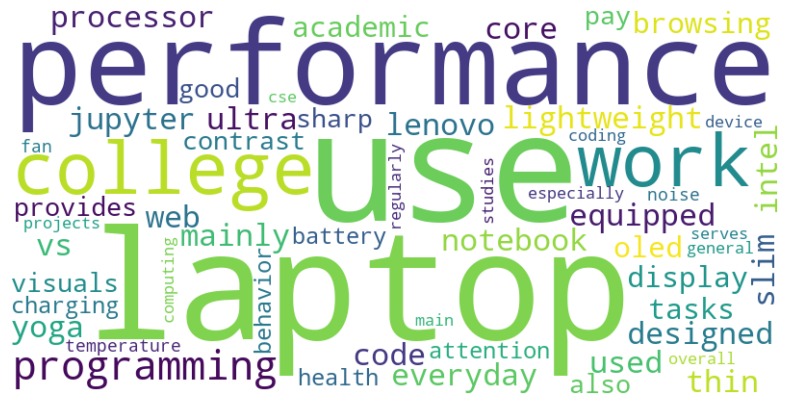

In [12]:
# Plotting the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
## Spam detector
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Toy Training Dataset
training_sentences = [
    "Claim your free gift card worth $1000 now",
    "URGENT! You have won a lottery, click here to claim",
    "Win cash prizes and free bonuses today",
    "Hey, are we still meeting for group study at 5 PM?",
    "Please find attached the project submission document",
    "Can you share the lecture notes for tomorrow's class?",
]
labels = ["Spam", "Spam", "Spam", "Ham", "Ham", "Ham"]  # 'Ham' means legitimate

# 2. Convert text sentences into numerical feature vectors (Bag of Words)
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(training_sentences)

# 3. Train Naive Bayes Classifier
classifier = MultinomialNB()
classifier.fit(X_train, labels)

print("Spam Detector Model Trained Successfully!\n")

# 4. Test with unseen sample messages
test_messages = [
    "Congratulations! You won a free prize call now",
    "Hey Rahul, let's complete the lab assignment tonight",
]

X_test = vectorizer.transform(test_messages)
predictions = classifier.predict(X_test)

for msg, pred in zip(test_messages, predictions):
  print(f"Message: '{msg}'")
  print(f"Prediction: [{pred}]\n")

Spam Detector Model Trained Successfully!

Message: 'Congratulations! You won a free prize call now'
Prediction: [Spam]

Message: 'Hey Rahul, let's complete the lab assignment tonight'
Prediction: [Ham]

